In [1]:
import logging
import os
import warnings

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

import arviz as az
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ssms.basic_simulators import Simulator

import hssm

hssm.set_floatX("float64")
# A generated ipynb runs outside the marimo editor, so targeted Jupyter CI
# automatically follows the complete static path. The explicit override is
# needed while `marimo export --include-outputs` runs inside marimo itself.
static_docs = os.environ.get("HSSM_DOCS_STATIC") == "1" or not mo.running_in_notebook()
full_run = os.environ.get("FULL_RUN") == "1"
run_config = (
    {
        "mode": "full",
        "sim_trials": 3000,
        "data_trials": 300,
        "draws": 500,
        "tune": 300,
        "chains": 2,
        "ppc_draws": 100,
    }
    if full_run
    else {
        "mode": "quick",
        "sim_trials": 750,
        "data_trials": 80,
        "draws": 20,
        "tune": 20,
        "chains": 1,
        "ppc_draws": 20,
    }
)

Setting PyTensor floatX type to float64.


Setting "jax_enable_x64" to True. If this is not intended, please set `jax` to False.


# Attentional DDM (aDDM)

The aDDM extends the DDM with **gaze-dependent drift**: while a decision maker
fixates one item, evidence for that item accumulates faster. Each trial carries
its own fixation sequence as covariates (`r1, r2, flag, sacc_array, d, sigma`),
and the core parameters `eta, kappa, a, b, x0` (+ a non-decision time `t`) can
be **regressed** on trial-level predictors.

This notebook: **(1)** poke the simulator, **(2)** see the covariate handshake,
**(3)** fit a trial-wise regression and recover it. The simulator is driven via
ssm-simulators' high-level `Simulator` class — the same path HSSM's PPC uses.

**Execution status.** The published page consumes a committed full-run static
export from this marimo source without re-executing it. Live marimo keeps the
controls interactive and gates sampling behind a button. Jupyter uses fixed
controls and executes the complete path (a quick check by default; set
`FULL_RUN=1` for the full publication configuration).

In [2]:
sim = Simulator(
    "addm"
)  # configure the aDDM simulator once (params [eta,kappa,a,b,x0,t])


def make_fixations(n, max_d=8, seed=0):
    """A batch of observed fixation sequences (the aDDM covariates)."""
    rng = np.random.default_rng(seed)
    r1 = rng.integers(1, 6, n).astype(np.float64)
    r2 = rng.integers(1, 6, n).astype(np.float64)
    flag = rng.integers(0, 2, n).astype(np.int64)
    d = rng.integers(2, max_d + 1, n).astype(np.int32)
    sacc = np.zeros((n, max_d))
    for i in range(n):
        sacc[i, 1 : d[i]] = np.sort(rng.uniform(0.1, 1.2, d[i] - 1))
    return dict(n=n, r1=r1, r2=r2, flag=flag, d=d, sacc=sacc)


def extra_fields(fixations):
    """Pack fixations into the extra_fields dict the simulator conditions on."""
    n = fixations["n"]
    return {
        "r1": fixations["r1"],
        "r2": fixations["r2"],
        "flag": fixations["flag"],
        "sacc_array": fixations["sacc"],
        "d": fixations["d"],
        "sigma": np.ones(n),
    }


fix = make_fixations(run_config["sim_trials"], seed=0)

## 1. Explore the simulator

Move the sliders to change the aDDM parameters and watch the reaction-time
distribution (split by choice) and the choice proportion update. `eta` is the
attentional discount (how strongly the *unattended* item is down-weighted),
`kappa` scales the drift, `a` is the boundary height, and `b` the collapse rate.

In [3]:
if static_docs:
    sim_parameters = {"eta": 0.3, "kappa": 1.0, "a": 1.5, "b": 0.2}
    _controls = mo.md(
        "**Parameters used for the static output:** "
        "`eta=0.3`, `kappa=1.0`, `a=1.5`, `b=0.2`. "
        "Open the marimo source to explore other values interactively."
    )
else:
    _eta = mo.ui.slider(0.0, 1.0, value=0.3, step=0.05, label="eta (attention)")
    _kappa = mo.ui.slider(0.1, 3.0, value=1.0, step=0.1, label="kappa (drift scale)")
    _a = mo.ui.slider(0.5, 3.0, value=1.5, step=0.1, label="a (boundary)")
    _b = mo.ui.slider(0.0, 1.0, value=0.2, step=0.05, label="b (collapse)")
    sim_parameters = {
        "eta": _eta.value,
        "kappa": _kappa.value,
        "a": _a.value,
        "b": _b.value,
    }
    _controls = mo.vstack([_eta, _kappa, _a, _b])
_controls

_md()

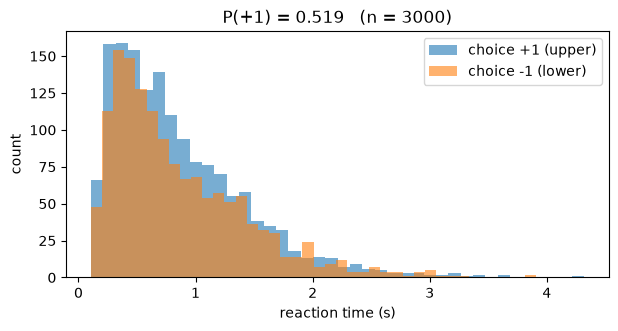

In [4]:
def simulate(eta, kappa, a, b, fixations, seed=1):
    # theta is (n_trials, 6) = [eta, kappa, a, b, x0, t]; one row per fixation
    # trial (all sharing these params here), n_samples=1 draw each.
    n = fixations["n"]
    theta = np.tile([eta, kappa, a, b, 0.0, 0.0], (n, 1))
    out = sim.simulate(
        theta=theta,
        n_samples=1,
        random_state=seed,
        max_t=10.0,
        extra_fields=extra_fields(fixations),  # Mode 2: condition on fixations
    )
    rt = np.asarray(out["rts"]).reshape(-1)
    ch = np.asarray(out["choices"]).reshape(-1)
    keep = rt != -999.0
    return rt[keep], ch[keep]


_rt, _ch = simulate(**sim_parameters, fixations=fix)
_fig, _ax = plt.subplots(figsize=(7, 3.2))
_ax.hist(_rt[_ch == 1], bins=40, alpha=0.6, label="choice +1 (upper)")
_ax.hist(_rt[_ch == -1], bins=40, alpha=0.6, label="choice -1 (lower)")
_ax.set_xlabel("reaction time (s)")
_ax.set_ylabel("count")
_ax.set_title(f"P(+1) = {np.mean(_ch == 1):.3f}   (n = {_rt.size})")
_ax.legend()
plt.close(_fig)
_fig

## 2. The covariate handshake

An aDDM prediction depends on the **fixation sequence**, so a posterior- (or
prior-) predictive check must reuse the *observed* gaze pattern, not invent a
new one. The simulator supports two modes:

* **Mode 2 (conditioned)** — pass `extra_fields` with the observed `r1, r2,
  flag, sacc_array, d`; only the trajectory is sampled.
* **Mode 1 (self-sampled)** — omit `extra_fields`, so it samples its own.

Below, the same `Simulator` runs both ways. The distributions differ — that
difference is exactly what the PPC handshake preserves.

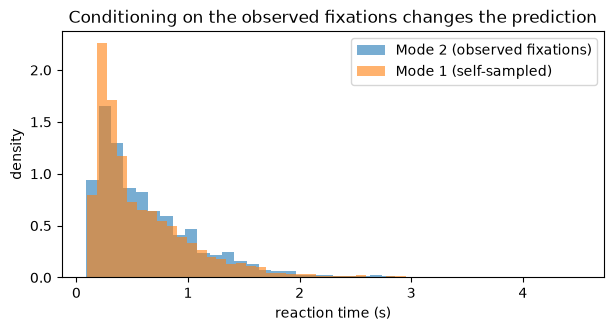

In [5]:
_theta = np.tile([0.3, 1.5, 1.5, 0.2, 0.0, 0.0], (fix["n"], 1))

# Mode 2: pass the observed fixations via extra_fields.
_cond = sim.simulate(
    theta=_theta,
    n_samples=1,
    random_state=7,
    max_t=10.0,
    extra_fields=extra_fields(fix),
)
# Mode 1: same params + seed, but no extra_fields -> self-sampled fixations.
_self = sim.simulate(theta=_theta, n_samples=1, random_state=7, max_t=10.0)


def _valid(out):
    rt = np.asarray(out["rts"]).reshape(-1)
    return rt[rt != -999.0]


_fig, _ax = plt.subplots(figsize=(7, 3.2))
_ax.hist(
    _valid(_cond),
    bins=40,
    alpha=0.6,
    density=True,
    label="Mode 2 (observed fixations)",
)
_ax.hist(_valid(_self), bins=40, alpha=0.6, density=True, label="Mode 1 (self-sampled)")
_ax.set_xlabel("reaction time (s)")
_ax.set_ylabel("density")
_ax.set_title("Conditioning on the observed fixations changes the prediction")
_ax.legend()
plt.close(_fig)
_fig

### How the handshake is wired

The likelihood already receives the fixations (as `extra_fields`); the
*generative* path did not, so it used to self-sample. The fix threads the
observed covariates through, end to end — the last two steps are the very
`Simulator`/`simulator()` API used above:

```
aDDM._make_model_distribution / _update_extra_fields   (HSSM)
    └─ stashes {r1,r2,flag,sacc_array,d,sigma} on the RV class: rv_op._extra_fields
HSSMRV.rng_fn        (HSSM)            forwards _extra_fields ->
ssms_rng_fn          (ssm-simulators) broadcasts to (draws x trials) ->
simulator(..., extra_fields=dict)     splats into ->   (Simulator.simulate too)
cssm.addm(..., sacc_array=...)        Mode 2: conditions on the observed fixations
```

You can see the stashed covariates on the built model in section 4.

## 3. Simulate a dataset with a trial-wise `eta`

A per-trial predictor `x` drives `eta`: `eta_i = 0.2 + 0.3 * x_i` (the target we
will recover). Observed fixations are truncated at the response — you only see
fixations that started before the decision, and the likelihood requires
`rt >= sacc[d-1]`.

In [6]:
_f = make_fixations(run_config["data_trials"], seed=42)
_n = _f["n"]
x = np.random.default_rng(1).uniform(0.0, 1.0, _n)
_eta_true = 0.2 + 0.3 * x

# theta with a per-trial eta column; the rest shared.
_theta = np.column_stack(
    [
        _eta_true,
        np.full(_n, 1.0),
        np.full(_n, 1.5),
        np.full(_n, 0.2),
        np.zeros(_n),
        np.zeros(_n),
    ]
)
_out = sim.simulate(
    theta=_theta,
    n_samples=1,
    random_state=2,
    max_t=10.0,
    smooth_unif=False,
    extra_fields=extra_fields(_f),
)
_rt = np.asarray(_out["rts"]).reshape(-1)
_ch = np.asarray(_out["choices"]).reshape(-1).astype(float)
_keep = _rt != -999.0
_rows = np.flatnonzero(_keep)

_sacc, _d = _f["sacc"], _f["d"]
_d_obs = np.array([max(int((_sacc[i, : _d[i]] < _rt[i]).sum()), 1) for i in _rows])
data = pd.DataFrame(
    {
        "rt": _rt[_keep],
        "response": _ch[_keep],
        "x": x[_keep],
        "r1": _f["r1"][_keep],
        "r2": _f["r2"][_keep],
        "flag": _f["flag"][_keep].astype(int),
        "d": _d_obs,
        "sigma": np.full(_rows.size, 1.0),
    }
)
data["sacc_array"] = pd.Series([_sacc[i].copy() for i in _rows], index=data.index)
data.head()

,rt,response,x,r1,r2,flag,d,sigma,sacc_array
0,2.9385,-1.0,0.511822,1.0,2.0,1,2,1.0,"[0.0, 0.625256460990506, 0.0, 0.0, 0.0, 0.0, 0..."
1,0.2285,-1.0,0.950464,4.0,5.0,1,1,1.0,"[0.0, 0.9375758195024083, 0.0, 0.0, 0.0, 0.0, ..."
2,0.6285,1.0,0.144160,4.0,1.0,1,1,1.0,"[0.0, 0.8927655413901866, 1.0936606591604583, ..."
3,1.0705,1.0,0.948649,3.0,5.0,0,7,1.0,"[0.0, 0.2255144783020009, 0.5840975694801054, ..."
4,1.5295,-1.0,0.311831,3.0,3.0,1,5,1.0,"[0.0, 0.4170510700366958, 0.8195126504305924, ..."


## 4. Fit a trial-wise regression on `eta`

`include=[{"name": "eta", "formula": "eta ~ 1 + x"}]` makes `eta` vary per trial
as a linear function of `x`. This trial-wise / hierarchical support on the core
parameters is the headline aDDM capability.

In [7]:
model = hssm.aDDM(
    data=data,
    include=[{"name": "eta", "formula": "eta ~ 1 + x"}],
    initval_jitter=0,
)
model

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: addm

Response variable: rt,response
Likelihood: approx_differentiable
Observations: 300

Parameters:

eta:
    Formula: eta ~ 1 + x
    Priors:
        eta_Intercept ~ Normal(mu: 0.5, sigma: 0.25)
        eta_x ~ Normal(mu: 0.0, sigma: 0.25)
    Link: identity
    Explicit bounds: (0.0, 1.0)

kappa:
    Prior: Uniform(lower: 0.0, upper: 5.0)
    Explicit bounds: (0.0, 5.0)

a:
    Prior: Uniform(lower: 0.1, upper: 3.0)
    Explicit bounds: (0.1, 3.0)

b:
    Prior: Uniform(lower: 0.0, upper: 3.0)
    Explicit bounds: (0.0, 3.0)

x0:
    Prior: Uniform(lower: -1.0, upper: 1.0)
    Explicit bounds: (-1.0, 1.0)

t:
    Prior: Uniform(lower: 0.0, upper: 2.0)
    Explicit bounds: (0.0, 2.0)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

In [8]:
# The handshake, on the built model: the observed fixations are stashed on the
# RV class, ready for the generative (PPC) path to forward to the simulator.
_ef = type(model.model_distribution.rv_op)._extra_fields
_rows = "\n".join(
    f"    {k:<11} shape {tuple(np.asarray(v).shape)}  dtype {np.asarray(v).dtype}"
    for k, v in _ef.items()
)
mo.md(
    f"**`rv_op._extra_fields`** (observed fixations wired into PPC):\n\n```\n{_rows}\n```"
)

_md()

In [9]:
if static_docs:
    run_inference = True
    _mode = run_config["mode"]
    _full_run_marker = "true" if _mode == "full" else "false"
    _status = mo.md(
        "## 5. Fit and recover\n\n"
        f"The static artifact runs the **{_mode}** configuration: "
        f"{run_config['chains']} chain(s), {run_config['tune']} tuning draws, "
        f"and {run_config['draws']} retained draws. Initialization jitter is "
        "disabled (`initval_jitter=0`), and sampling uses the fixed seed "
        "`20240830`.\n\n"
        f"<!-- hssm-full-run-artifact: {_full_run_marker} -->\n"
        "<!-- hssm-deterministic-init: true -->"
    )
else:
    _button = mo.ui.run_button(label="Run inference")
    run_inference = _button.value
    _status = mo.md(
        "## 5. Fit and recover\n\n"
        f"{_button}\n\nSet `FULL_RUN=1` before opening marimo for the "
        "published 500-draw configuration."
    )
_status

_md()

In [10]:
# aDDM auto-selects the JAX numpyro NUTS sampler (approx_differentiable + jax
# backend), so this already samples in JAX. cores=1 keeps the chains sequential
# — measured to be the right call on CPU. A single chain uses only ~6 of 18
# cores, but the FPT gradient is memory-bandwidth-bound (it materializes
# per-term intermediates — the reason for TRUNC_NUM<=6), not core-bound, so the
# idle cores don't convert to speed and a 2nd chain just contends for the memory
# bus. Measured on 18 cores: 2 chains via spawn 1.97x, numpyro
# chain_method="vectorized" 2.86x, forced-device "parallel" 2.24x; PyMC fork
# (cores>1) deadlocks. Genuinely parallel chains want a GPU (numpyro
# chain_method="vectorized" vmaps both chains onto the one device).
if run_inference:
    idata = model.sample(
        draws=run_config["draws"],
        tune=run_config["tune"],
        chains=run_config["chains"],
        cores=1,
        random_seed=20240830,
        progressbar=False,
        idata_kwargs={"log_likelihood": False},
    )
else:
    idata = None

Using default initvals. 



NUTS[numpyro]: [a, x0, b, kappa, t, eta_Intercept, eta_x]


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [11]:
# Truth: eta_Intercept ~ 0.2, eta_x ~ 0.3, kappa 1, a 1.5, b 0.2, x0 0, t 0.
_summary = (
    az.summary(
        idata,
        var_names=["eta", "kappa", "a", "b", "x0", "t"],
        filter_vars="like",
    )
    if idata is not None
    else mo.md("*Run inference to display the recovery summary.*")
)
_summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,1.377,0.062,1.3,1.5,388,412,1.01,0.0031,0.002
eta_Intercept,0.244,0.054,0.15,0.33,773,637,1.01,0.002,0.0014
x0,0.016,0.035,-0.037,0.076,788,474,1.01,0.0013,0.00089
b,0.171,0.062,0.061,0.27,345,281,1.01,0.0034,0.0022
kappa,0.963,0.053,0.88,1,760,699,1.00,0.0019,0.0014
t,0.0135,0.0093,0.0013,0.03,504,426,1.00,0.00039,0.00028
eta_x,0.234,0.093,0.089,0.39,634,540,1.00,0.0037,0.0025


In [12]:
if idata is not None:
    _divergences = int(idata.sample_stats["diverging"].sum().item())
    _retained_draws = idata.posterior.sizes["chain"] * idata.posterior.sizes["draw"]
    # ArviZ returns a DataTree for direct diagnostics on PyMC 6 traces. Keep
    # this reader-facing boundary narrow by asking summary for an unrounded
    # DataFrame, the same normalized representation displayed just above.
    _exact_summary = az.summary(
        idata,
        var_names=["eta", "kappa", "a", "b", "x0", "t"],
        filter_vars="like",
        round_to="none",
    )
    _max_rhat = float(_exact_summary["r_hat"].max())
    _min_bulk_ess = float(_exact_summary["ess_bulk"].min())
    _diagnostic = mo.md(
        f"**Divergences:** {_divergences} across {_retained_draws} retained "
        "draws. Interpret this count together with recovery, trace shape, "
        "R-hat, and effective sample sizes.  \n"
        f"**Maximum rank-normalized R-hat:** `{_max_rhat!r}`; "
        f"**minimum bulk ESS:** `{_min_bulk_ess!r}`."
    )
else:
    _diagnostic = mo.md("*Run inference to display sampler diagnostics.*")
_diagnostic

_md()

### Diagnostics — is everything working as expected?

- **Recovery** (below): compare each blue posterior interval with the matching
  ground-truth value listed in the figure title.
- **Trace**: when multiple chains run, they should overlap and look like white
  noise (good mixing); also check `r_hat ~ 1.0` and `ess_bulk` in the summary
  above.
- **Pair**: look for funnels / tight ridges (hard geometry).
- **Posterior predictive** (§6): predicted RTs should track the observed ones.

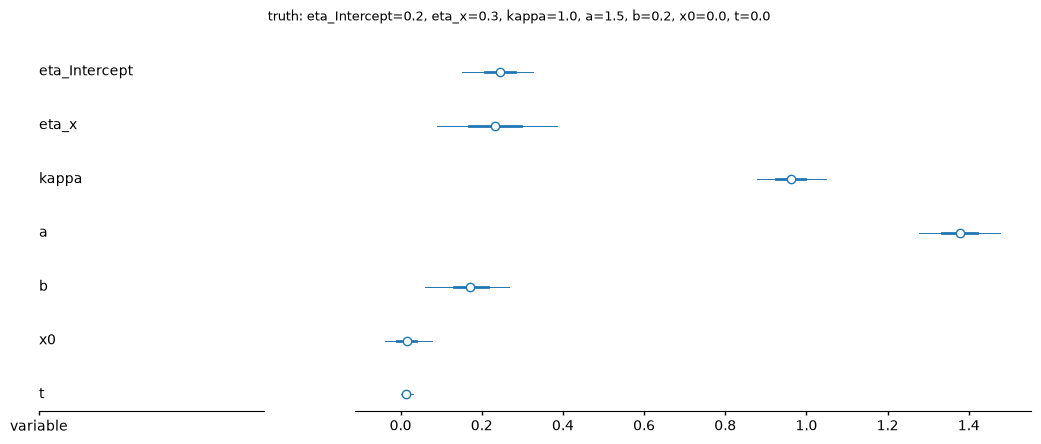

In [13]:
# Recovery: posteriors vs the ground-truth values used to simulate the data.
_truth = {
    "eta_Intercept": 0.2,
    "eta_x": 0.3,
    "kappa": 1.0,
    "a": 1.5,
    "b": 0.2,
    "x0": 0.0,
    "t": 0.0,
}
# arviz 1.x dropped `plot_posterior`/`ref_val`; forest intervals with the
# true values in the title give the same recovery-at-a-glance check.
if idata is not None:
    az.plot_forest(idata, var_names=list(_truth), combined=True)
    _fig = plt.gcf()
    _fig.suptitle(
        "truth: " + ", ".join(f"{k}={v}" for k, v in _truth.items()),
        fontsize=9,
    )
    plt.close(_fig)
else:
    _fig = None
_fig

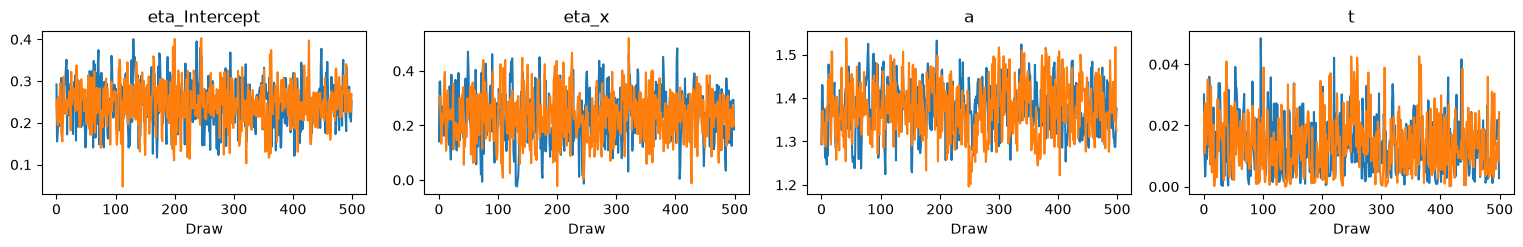

In [14]:
# Trace: chain mixing / convergence for a few key parameters.
if idata is not None:
    az.plot_trace(idata, var_names=["eta_Intercept", "eta_x", "a", "t"])
    plt.tight_layout()
    _trace = plt.gcf()
    plt.close(_trace)
else:
    _trace = None
_trace

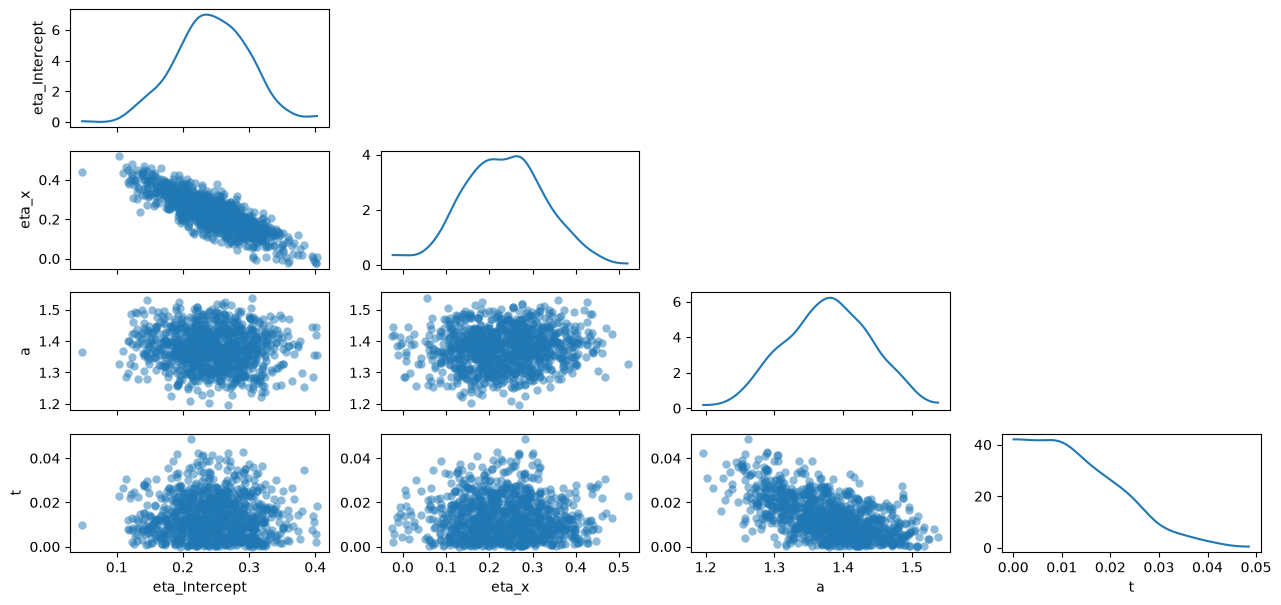

In [15]:
# Pair: posterior geometry + correlations. (arviz 1.x plot_pair dropped the
# `kind`/`divergences` kwargs.)
if idata is not None:
    az.plot_pair(
        idata,
        var_names=["eta_Intercept", "eta_x", "a", "t"],
    )
    _pair = plt.gcf()
    plt.close(_pair)
else:
    _pair = None
_pair

## 6. Posterior predictive checks

`sample_posterior_predictive` draws new (rt, choice) from the posterior. By default it
conditions on **each trial's observed fixation sequence** — the handshake from section 2
feeds the observed `r1, r2, flag, sacc_array, d` to the simulator, so the check is faithful
to the gaze pattern that produced the data.

Observed (pink) vs predicted (blue) RT densities below; `rt` is signed by choice, and
`x_range` zooms past the `p_outlier` lapse tail.

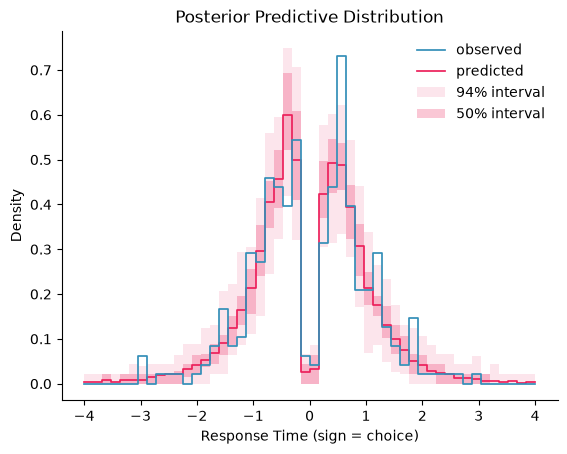

In [16]:
if idata is not None:
    model.sample_posterior_predictive(
        idata, kind="response", draws=run_config["ppc_draws"]
    )
    model.plot_predictive(x_range=(-4, 4))
    _ppc = plt.gcf()
    plt.close(_ppc)
else:
    _ppc = None
_ppc

### Fixation-continuation policies

A re-simulated particle may still be undecided when it reaches the **last observed
fixation** — the observed gaze sequence is right-censored at the response, so its last
fixation was cut short. How the fixation process is *continued* past that point is a
modelling choice, selectable **per PPC call** on the same fitted model (no re-fit) via
`continuation_mode` / `continuation_params`:

- **`prolong_last_fixation`** (default) — hold the last gaze's drift to `max_t`. The classic
  behaviour; byte-identical to before this option existed.
- **`sample_continuation`** — draw the continuation (tail) fixation durations from a chosen
  positive distribution and keep alternating gaze. This resamples the censored last fixation
  to a natural (uncensored) duration instead of freezing it.
- **`resample_all_fixations`** — ignore the observed fixation schedule entirely and
  self-sample the whole fixation behaviour (first gaze + durations), keeping only the
  observed stimulus (`r1`, `r2`). A fully generative check of the model's fixation process.

Distributions come from a `scipy.stats` positive-distribution factory (gamma, lognormal,
weibull, invgauss, …); `dist_params` are scipy-native (gamma's shape is `a`, so
`{"a": 6.0, "scale": 0.1}` is `Gamma(shape=6, scale=0.1)`).

pre-existing posterior_predictive group deleted from datatree.


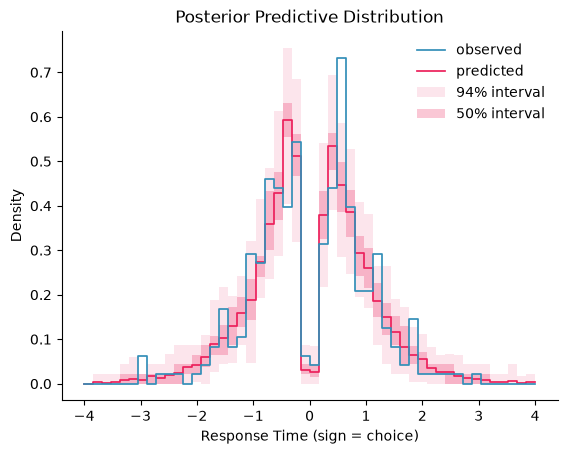

In [17]:
# Same fitted model, a different continuation policy — chosen per call, no re-fit.
_gamma = {"dist": "gamma", "dist_params": {"a": 6.0, "scale": 0.1}}
if idata is not None:
    model.sample_posterior_predictive(
        idata,
        kind="response",
        draws=run_config["ppc_draws"],
        continuation_mode="sample_continuation",
        continuation_params=_gamma,
    )
    model.plot_predictive(x_range=(-4, 4))
    _continuation_ppc = plt.gcf()
    plt.close(_continuation_ppc)
else:
    _continuation_ppc = None
_continuation_ppc

## 7. Model cartoon

`hssm.plotting.plot_model_cartoon` renders the fitted aDDM as a *cartoon*: the collapsing
decision bounds $\pm(a - b\,t)$, the drift path from the starting point $x_0$, a few
stochastic sample trajectories, the non-decision time, and the choice-split RT histograms
(observed vs predicted). It reads the geometry from *simulator* metadata, so it works for
the aDDM exactly as it does for the built-in SSMs.

> **Caveat — this is not the §6 PPC.** For the aDDM the cartoon re-simulates at the
> posterior-mean parameters with the simulator *self-sampling* its own gaze sequence
> (Mode 1), and its predictive uses the **default** continuation policy — the
> `continuation_mode` you set above does **not** reach it. Read the cartoon as a schematic
> of the fitted drift/boundary geometry, not as the fixation-conditioned predictive check
> of §6. Conditioning the cartoon on the observed fixations is tracked in
> [issue #1039](https://github.com/lnccbrown/HSSM/issues/1039).

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


Output()

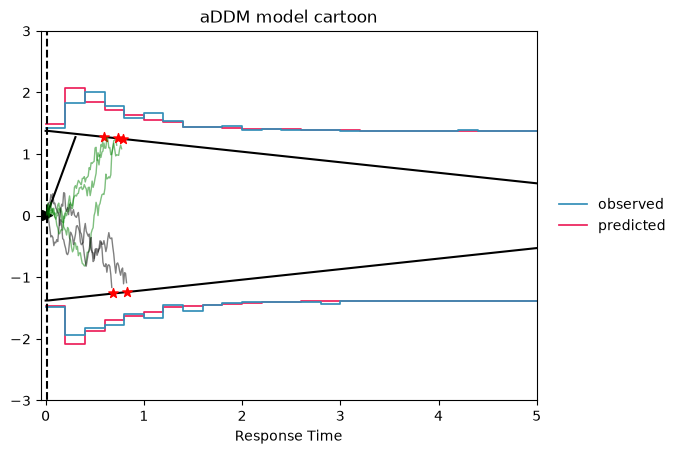

In [18]:
if idata is not None:
    hssm.plotting.plot_model_cartoon(
        model,
        dt=idata,
        n_samples=8,
        n_trajectories=5,
        bins=25,
        plot_predictive_mean=True,
        plot_predictive_samples=False,
        title="aDDM model cartoon",
    )
    _cartoon = plt.gcf()
    plt.close(_cartoon)
else:
    _cartoon = None
_cartoon